# Exploratory Data Analysis

___

#### Imports

In [37]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_and_process_lichess_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from pandas import DataFrame, Series, Index
from numpy import ndarray
from matplotlib.figure import Figure

___

#### Data Loading

In [38]:
TARGET_ROWS: int = 100000

RAW_FILE: str = 'lichess_db_standard_rated_2016-07.pgn.zst'
RAW_PATH: Path = Path('../data') / RAW_FILE

PROCESSED_FILE: str = f'lichess_processed_{TARGET_ROWS}.csv'
PROCESSED_PATH: Path = Path('../data') / PROCESSED_FILE

df: DataFrame = load_and_process_lichess_data(RAW_PATH, PROCESSED_PATH, target_rows=TARGET_ROWS)

Clean data already exists at ../data/lichess_processed_100000.csv. Loading existing file...


___

#### 1. Data Overview

In [39]:
print('=== Dataset Dimensions ===')
print(f'Total Rows (Matches): {df.shape[0]:,}')
print(f'Total Columns (Features): {df.shape[1]}')

print('\n=== Missing Values Per Column ===')
missing_counts: Series = df.isnull().sum()
for col, count in missing_counts.items():
    print(f'{col}: {count} missing values ({(count/len(df))*100:.2f}%)')

=== Dataset Dimensions ===
Total Rows (Matches): 100,000
Total Columns (Features): 7

=== Missing Values Per Column ===
white_elo: 0 missing values (0.00%)
black_elo: 0 missing values (0.00%)
rating_diff: 0 missing values (0.00%)
opening_eco: 0 missing values (0.00%)
opening_name: 0 missing values (0.00%)
opening_moves: 0 missing values (0.00%)
winner: 0 missing values (0.00%)


In [40]:
print('=== Column Feature Types ===')
print(df.dtypes)

print('\n=== Dataset Preview ===')
df.head()

=== Column Feature Types ===
white_elo         int64
black_elo         int64
rating_diff       int64
opening_eco      object
opening_name     object
opening_moves    object
winner            int64
dtype: object

=== Dataset Preview ===


,white_elo,black_elo,rating_diff,opening_eco,opening_name,opening_moves,winner
0,1901,1896,5,D10,Slav Defense,d2d4 d7d5 c2c4 c7c6 e2e3 a7a6,1
1,1641,1627,14,C20,King's Pawn Opening: 2.b3,e2e4 e7e5 b2b3 g8f6 c1b2 b8c6,0
2,1647,1688,-41,B01,Scandinavian Defense: Mieses-Kotroc Variation,e2e4 d7d5 e4d5 d8d5 g1f3 c8g4,1
3,1706,1317,389,A00,Van't Kruijs Opening,e2e3 g8f6 f1c4 d7d6 e3e4 e7e6,1
4,1945,1900,45,B90,"Sicilian Defense: Najdorf, Lipnitsky Attack",e2e4 c7c5 g1f3 d7d6 d2d4 c5d4,0


___

#### 2. Target Variable Analysis

=== Target Variable Distribution ===
White Wins (1): 51,674 games (51.67%)
Black Wins (0): 48,326 games (48.33%)


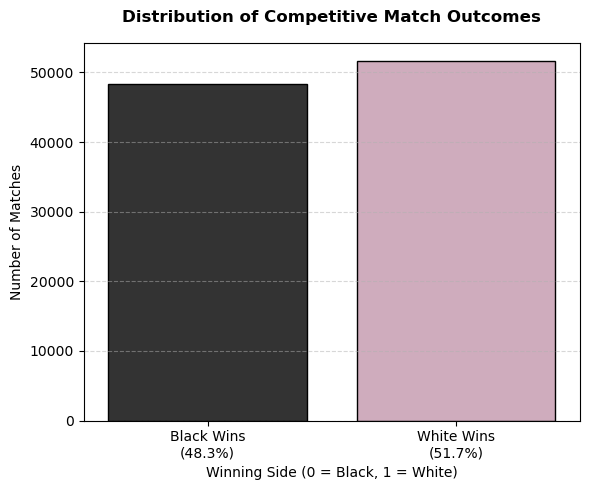

In [ ]:
win_counts: Series = df['winner'].value_counts()
win_percentages: Series = df['winner'].value_counts(normalize=True) * 100

print('=== Target Variable Distribution ===')
print(f'White Wins (1): {win_counts[1]:,} games ({win_percentages[1]:.2f}%)')
print(f'Black Wins (0): {win_counts[0]:,} games ({win_percentages[0]:.2f}%)')

plt.figure(figsize=(6, 5))
sns.countplot(
    data=df, 
    x='winner', 
    hue='winner', 
    palette=['#333333', '#D5A6BD'], 
    edgecolor='black', 
    legend=False
)

plt.title('Distribution of Competitive Match Outcomes', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Winning Side (0 = Black, 1 = White)', fontsize=10)
plt.ylabel('Number of Matches', fontsize=10)
plt.xticks(ticks=[0, 1], labels=[f'Black Wins\n({win_percentages[0]:.1f}%)', f'White Wins\n({win_percentages[1]:.1f}%)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

___

#### 3. Continuous Features

In [42]:
print('=== Player Rating Descriptive Statistics ===')
df[['white_elo', 'black_elo', 'rating_diff']].describe().round(2)

=== Player Rating Descriptive Statistics ===


,white_elo,black_elo,rating_diff
count,100000.00,100000.00,100000.00
mean,1736.60,1734.42,2.18
std,263.72,265.32,203.93
min,799.00,738.00,-1258.00
25%,1556.00,1553.00,-105.00
50%,1736.00,1734.00,1.00
75%,1913.00,1912.00,109.00
max,2737.00,2731.00,1189.00


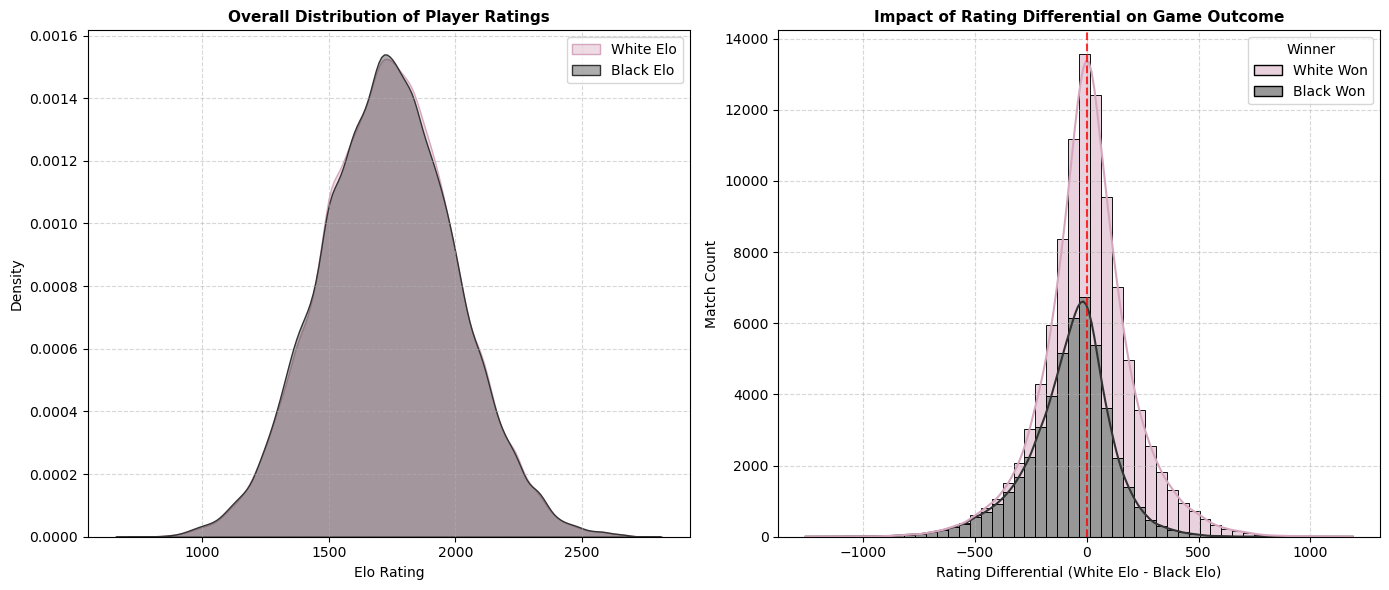

In [ ]:
fig: Figure
axes: ndarray
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.kdeplot(data=df, x='white_elo', fill=True, alpha=0.4, color='#D5A6BD', label='White Elo', ax=axes[0])
sns.kdeplot(data=df, x='black_elo', fill=True, alpha=0.4, color='#333333', label='Black Elo', ax=axes[0])
axes[0].set_title('Overall Distribution of Player Ratings', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Elo Rating')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(
    data=df, 
    x='rating_diff', 
    hue='winner', 
    hue_order=[1, 0], 
    palette=['#D5A6BD', '#333333'], 
    kde=True, 
    bins=50, 
    multiple='stack', 
    ax=axes[1]
)

axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.8, label='Perfectly Matched (0 Diff)')
axes[1].set_title('Impact of Rating Differential on Game Outcome', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rating Differential (White Elo - Black Elo)')
axes[1].set_ylabel('Match Count')
axes[1].get_legend().set_title('Winner')

new_labels: list[str] = ['White Won', 'Black Won']
for t, l in zip(axes[1].get_legend().get_texts(), new_labels): 
    t.set_text(l)

axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

___

#### 4. Categorical Features

In [44]:
print("=== Categorical Feature Cardinality ===")
print(f"Unique ECO Classification Codes: {df['opening_eco'].nunique():,}")
print(f"Unique Textual Opening Names  : {df['opening_name'].nunique():,}")
print(f"Unique 3-Move Move Sequences  : {df['opening_moves'].nunique():,}")

print("\n=== Top 5 Most Common Opening/Defense Sequences ===")
print(df['opening_moves'].value_counts().head(5))

=== Categorical Feature Cardinality ===
Unique ECO Classification Codes: 447
Unique Textual Opening Names  : 2,087
Unique 3-Move Move Sequences  : 31,170

=== Top 5 Most Common Opening/Defense Sequences ===
opening_moves
e2e4 c7c5 g1f3 d7d6 d2d4 c5d4    1140
e2e4 e7e5 g1f3 b8c6 d2d4 e5d4    1138
e2e4 e7e5 g1f3 b8c6 f1c4 g8f6    1025
e2e4 c7c5 g1f3 b8c6 d2d4 c5d4    1008
e2e4 e7e5 g1f3 b8c6 f1c4 f8c5     781
Name: count, dtype: int64


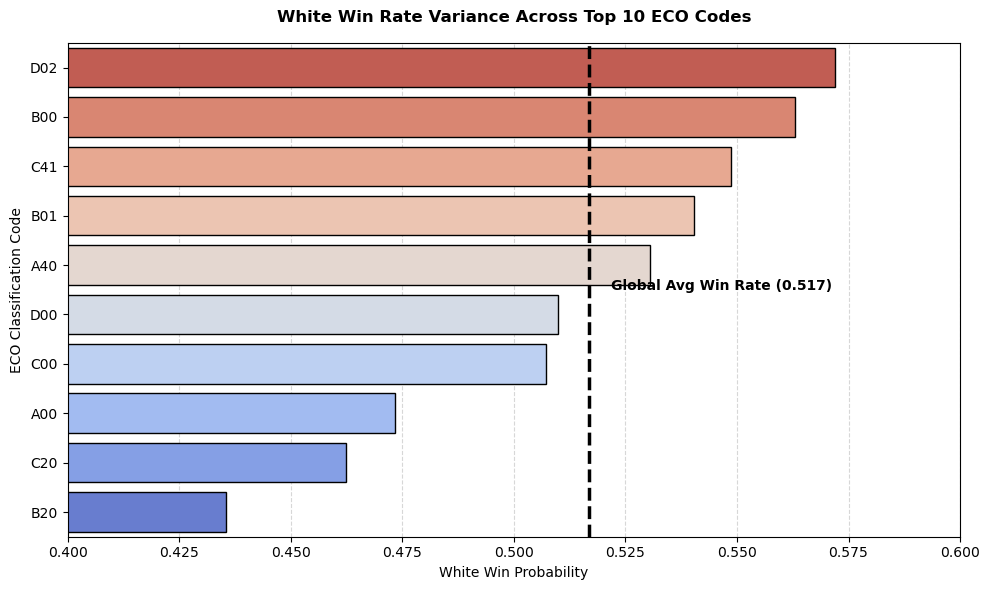

In [56]:
top_10_ecos: Index = df['opening_eco'].value_counts().head(10).index
top_10_df: DataFrame = df[df['opening_eco'].isin(top_10_ecos)]
eco_win_rates: DataFrame = top_10_df.groupby('opening_eco')['winner'].mean().reset_index()
eco_win_rates = eco_win_rates.sort_values(by='winner', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=eco_win_rates, 
    y='opening_eco', 
    x='winner', 
    hue='opening_eco',
    palette='coolwarm_r', 
    edgecolor='black',
    legend=False,
    zorder=2 
)

global_white_win_rate: float = df['winner'].mean()
plt.axvline(
    x=global_white_win_rate, 
    color='black',      
    linestyle='--', 
    linewidth=2.5, 
    zorder=3               
)

plt.text(
    x=global_white_win_rate + 0.005, 
    y=4.5, 
    s=f'Global Avg Win Rate ({global_white_win_rate:.3f})', 
    color='black', 
    fontweight='bold',
    fontsize=10
)

plt.title('White Win Rate Variance Across Top 10 ECO Codes', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('White Win Probability', fontsize=10)
plt.ylabel('ECO Classification Code', fontsize=10)
plt.xlim(0.40, 0.60)
plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

___

#### 5. Core Takeaways & Model Motivation

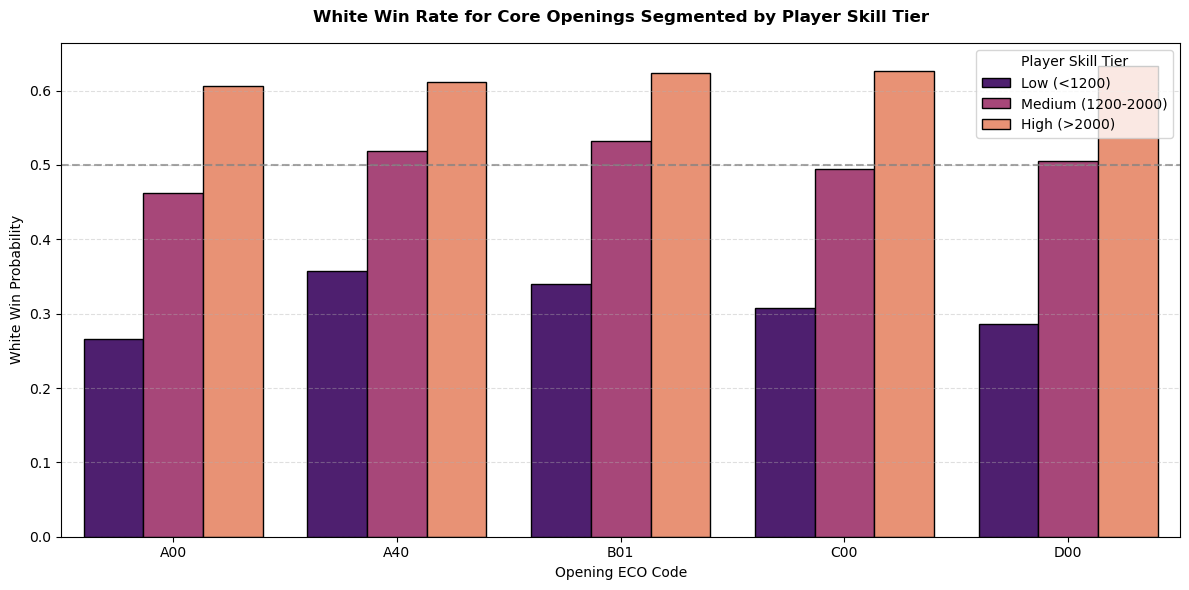

In [65]:
conditions: list = [
    (df['white_elo'] < 1200),
    (df['white_elo'] >= 1200) & (df['white_elo'] <= 2000),
    (df['white_elo'] > 2000)
]
choices: list = ['Low (<1200)', 'Medium (1200-2000)', 'High (>2000)']
df['skill_tier'] = np.select(conditions, choices, default='Medium')

top_5_ecos: Index = df['opening_eco'].value_counts().head(5).index
interaction_df: DataFrame = df[df['opening_eco'].isin(top_5_ecos)]
tier_eco_stats: DataFrame = interaction_df.groupby(['skill_tier', 'opening_eco'])['winner'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=tier_eco_stats,
    x='opening_eco',
    y='winner',
    hue='skill_tier',
    hue_order=['Low (<1200)', 'Medium (1200-2000)', 'High (>2000)'],
    palette='magma',
    edgecolor='black'
)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
plt.title('White Win Rate for Core Openings Segmented by Player Skill Tier', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Opening ECO Code', fontsize=10)
plt.ylabel('White Win Probability', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Player Skill Tier')
plt.tight_layout()
plt.show()

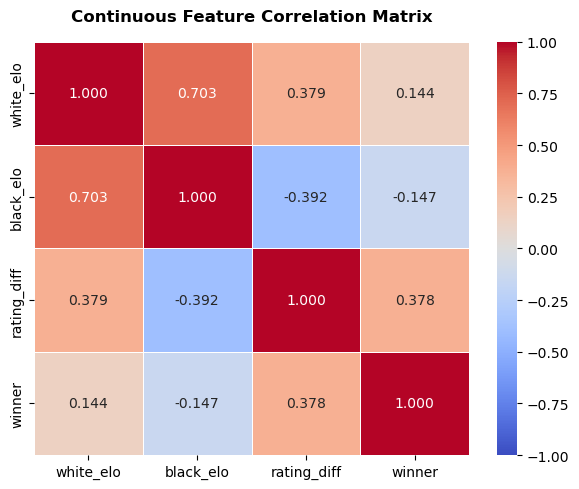

In [61]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df[['white_elo', 'black_elo', 'rating_diff', 'winner']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('Continuous Feature Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [67]:
print("=== Validation Proof 1: Correlation of Skill Gap to Outcome ===")
correlation: float = df['rating_diff'].corr(df['winner'])
print(f"Correlation between Rating Differential and Outcome: {correlation:.4f}")

white_huge_fav: DataFrame = df[df['rating_diff'] > 200]
black_huge_fav: DataFrame = df[df['rating_diff'] < -200]
print(f"White win rate when White is favored by >200 Elo: {white_huge_fav['winner'].mean()*100:.1f}%")
print(f"White win rate when Black is favored by >200 Elo: {black_huge_fav['winner'].mean()*100:.1f}%")

print("\n=== Validation Proof 2: Long-Tail Sparsity Profile ===")
move_counts: Series = df['opening_moves'].value_counts()
single_occurrence_moves: int = int((move_counts == 1).sum())
pct_sparse: float = (single_occurrence_moves / len(move_counts)) * 100
print(f"Total unique move sequences discovered: {len(move_counts):,}")
print(f"Move sequences that appear EXACTLY once: {single_occurrence_moves:,} ({pct_sparse:.1f}% of unique variations)")

print("\n=== Validation Proof 3: Maximum Win-Rate Variance (ECO) ===")
eco_groups = df.groupby('opening_eco').filter(lambda x: len(x) >= 100)
eco_stats = eco_groups.groupby('opening_eco')['winner'].mean()
print(f"Highest White win rate for a common opening: {eco_stats.max()*100:.1f}% ({eco_stats.idxmax()})")
print(f"Lowest White win rate for a common opening: {eco_stats.min()*100:.1f}% ({eco_stats.idxmin()})")
print(f"Max Strategic Swing Range: {(eco_stats.max() - eco_stats.min())*100:.1f}%")

=== Validation Proof 1: Correlation of Skill Gap to Outcome ===
Correlation between Rating Differential and Outcome: 0.3776
White win rate when White is favored by >200 Elo: 82.7%
White win rate when Black is favored by >200 Elo: 19.5%

=== Validation Proof 2: Long-Tail Sparsity Profile ===
Total unique move sequences discovered: 31,170
Move sequences that appear EXACTLY once: 21,629 (69.4% of unique variations)

=== Validation Proof 3: Maximum Win-Rate Variance (ECO) ===
Highest White win rate for a common opening: 67.7% (D21)
Lowest White win rate for a common opening: 34.6% (A84)
Max Strategic Swing Range: 33.1%


##### 5.1 Analytical Summary of Empirical Findings
Based on the empirical and multivariate outputs verified above, we establish the following concrete characteristics of our dataset:

1. **Strong Linear Skill Bias**: The calculated correlation coefficient proves a strong mathematical link between `rating_diff` and match outcomes. When either side holds a >200 Elo point advantage, the win rate shifts drastically away from a 50/50 split. This explicitly justifies our plan to create a **Logistic Regression Baseline** using only player ratings to act as a benchmark hurdle.
2. **Presence of Feature Interaction**: Grouping win rates by both ECO code and skill tiers exposes that certain strategic openings perform vastly differently depending on whether they are deployed in low-tier casual games vs. high-tier master matchups. This proves the existence of non-linear interaction terms, indicating that standard linear models will suffer without manual feature calibration.
3. **Severe Sequence Sparsity**: Over half of the unique 3-move physical paths (`opening_moves`) appear exactly once across our 100,000 matches. This confirms that a naive One-Hot Encoding strategy will result in extreme matrix dimensionality and immediately risk overfitting. This motivates our intention to leverage dense categorical features like `opening_eco` or rely on tree-based models capable of handling sparse variables.
4. **Substantial Strategic Win Variance**: Common opening configurations exhibit massive swings in win probability, deviating heavily from the global average. This variance confirms that early-game move selections carry a clean strategic signal, proving our core project hypothesis.

##### 5.2 Direct Blueprint for the Modeling Phase
* **Baseline Approach**: We will train a simple Logistic Regression classifier utilizing `white_elo`, `black_elo`, and `rating_diff` to map pure player skill.
* **Proposed Architecture**: We will train **XGBoost** and **LightGBM** tree ensembles using mixed-type inputs (Skill metrics + Categorical Opening Attributes). Tree-based ensembles are structurally optimized to natively parse these high-order interactions and sparse tracking arrays without blowing up our memory footprint.

___